# Notebook angle estimation machine learning part
This notebook contains the code that is used to train the model for predicting the best angle at which the angiography should be taken 

In [ ]:
import pandas as pd
import torch 
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision.io import read_image

DATA_PATH = "dataset/" #Do not change folder structure that was created by Kasper
# dataset/
#   DRR_images/
#       [n].png
#   excel/
#       *.xlsx 


In [5]:
torch.__version__

'2.6.0+cu126'

In [3]:
torch.cuda.is_available()

True

## Loading labels

In [ ]:
labels = pd.read_excel(DATA_PATH+"excel/all_DRR_scores.xlsx")
labels['fullpath'] = DATA_PATH+"DRR_images/"+labels['DRR filename']+".png"
#labels.iloc[0]['fullpath']
labels

,DRR filename,aneurysm score,neck score,score,fullpath
0,C0001_X0_Y0,12.272727,1.783784,14.056511,dataset/DDR_images/C0001_X0_Y0.png
1,C0001_X10_Y0,7.358974,1.584906,8.943880,dataset/DDR_images/C0001_X10_Y0.png
2,C0001_X20_Y0,5.538462,1.921569,7.460030,dataset/DDR_images/C0001_X20_Y0.png
3,C0001_X30_Y0,5.309091,2.074074,7.383165,dataset/DDR_images/C0001_X30_Y0.png
4,C0001_X40_Y0,4.949153,1.689189,6.638342,dataset/DDR_images/C0001_X40_Y0.png
...,...,...,...,...,...
6835,C0074_X310_Y180,2.008721,2.130435,4.139156,dataset/DDR_images/C0074_X310_Y180.png
6836,C0074_X320_Y180,1.817175,1.709091,3.526265,dataset/DDR_images/C0074_X320_Y180.png
6837,C0074_X330_Y180,1.527578,2.289474,3.817052,dataset/DDR_images/C0074_X330_Y180.png
6838,C0074_X340_Y180,3.066038,2.050000,5.116038,dataset/DDR_images/C0074_X340_Y180.png


### Model

In [80]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.input = nn.Conv2d(in_ch, out_ch, 1, padding=1)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.maxpool = nn.MaxPool2d(4)
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(16, 1)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.maxpool(x)
        x = self.flatten(x)
        x = self.linear(x)
        return x

### DataLoader

In [52]:
class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self):
        self.img_labels = pd.read_excel(DATA_PATH+"excel/all_DRR_scores.xlsx")
        self.img_labels['fullpath'] = DATA_PATH+"DRR_images/"+self.img_labels['DRR filename']+".png"
        self.img_dir = DATA_PATH+"DRR_images"
        self.transform = None
        self.target_transform = None
    
    def __len__(self):
        return len(self.img_labels)
    
    def __getitem__(self, idx):
        image = plt.imread(self.img_labels.iloc[idx]["fullpath"])
        label = self.img_labels.iloc[idx]["score"]
        return image, label

train_dataloader = DataLoader = torch.utils.data.DataLoader(CustomImageDataset(), batch_size=64, shuffle=True)


Feature batch shape: torch.Size([64, 256, 256])
Labels batch shape: torch.Size([64])


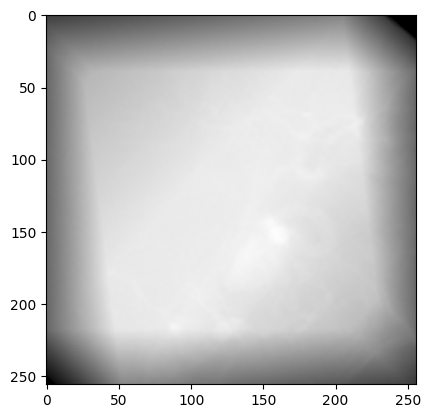

Label: 4.351312926156971


In [57]:
train, label = next(iter(train_dataloader))
print(f"Feature batch shape: {train.size()}")
print(f"Labels batch shape: {label.size()}")
img = train[0].squeeze()
label = label[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [81]:
device = torch.accelerator.current_accelerator()
model = Block(256,256).to(device)
print(model)

Block(
  (input): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
  (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=16, out_features=1, bias=True)
)


In [82]:
logit = model(train_dataloader)

TypeError: conv2d() received an invalid combination of arguments - got (DataLoader, Parameter, Parameter, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, tuple of ints padding = 0, tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!DataLoader!, !Parameter!, !Parameter!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, str padding = "valid", tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!DataLoader!, !Parameter!, !Parameter!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)
